In [1]:
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow_probability as tfp
from utils import CORR, UNCORR, CORR_FT, UNCORR_FT, plot_availability_heatmap
from gaussian_process_models.experiments import exp3
from gaussian_process_models.utils import get_cov_mat
import pandas as pd

2025-04-30 18:46:25.415211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746031585.427543 1387438 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746031585.431314 1387438 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746031585.440629 1387438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746031585.440649 1387438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746031585.440650 1387438 computation_placer.cc:177] computation placer alr

In [2]:
countries = [i+1 for i in range(7)]

# Create Mat for spatial correlation 2

In [3]:
formatted_array = list(range(100))

In [4]:
meafns = {'C0':np.array([0 for _ in range(25)] + [0.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C1':np.array([0 for _ in range(25)] + [0.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C2':np.array([0 for _ in range(25)] + [0.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C3':np.array([0 for _ in range(25)] + [0.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C4':np.array([0 for _ in range(50)] + [0.5 for _ in range(50)]),
          'C5':np.array([0 for _ in range(50)] + [0.5 for _ in range(50)]),
          'C6':np.array([0 for _ in range(50)] + [0.5 for _ in range(50)])
          }


In [5]:
freq = 0.50
rounds = 100
ft=10

res = exp3(freq1=freq, mean_seq=meafns,periodic_length_scale=1.0, period=0.6, amplitude=0.38, k=ft, seq_len=rounds, n_clients=7)

2025-04-30 18:46:26.533853: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-30 18:46:26.533871: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-04-30 18:46:26.533875: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-04-30 18:46:26.533878: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-04-30 18:46:26.533880: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: demouser
2025-04-30 18:46:26.533882: I external/local_xla/xla/stream_executor/cuda/cuda

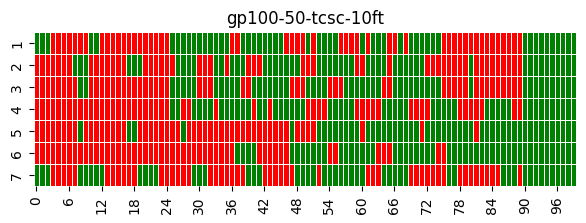

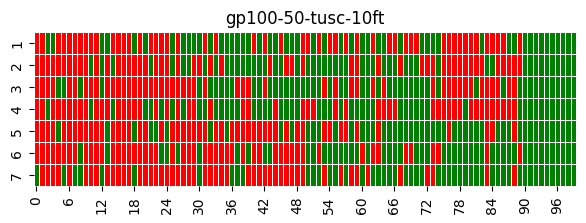

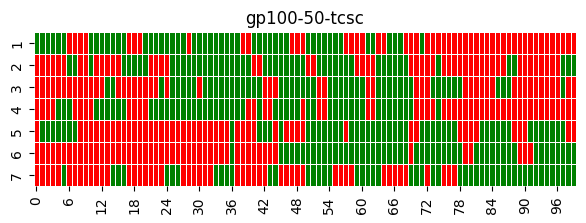

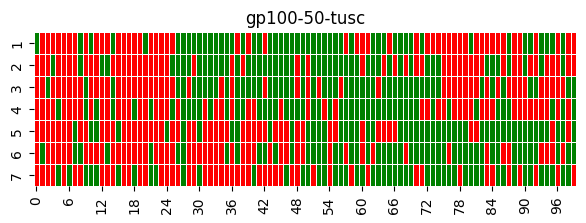

In [6]:
folder = 'availability_matrices/av-mat-8'

tmp = res[CORR_FT]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tcsc-' + str(ft) + 'ft'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

tmp = res[UNCORR_FT]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tusc-' + str(ft) + 'ft'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

tmp = res[CORR]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tcsc'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

tmp = res[UNCORR]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tusc'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)
